# Лабораторна 1. Основні бібліотеки. Лінійні моделі навчання.

В цій лабораторній роботі студенти:
- ознайомлюються з сервісом Colab;
- ознайомлюються з базовими бібліотеками для машинного навчання;
- тренують неглибокі лінійні моделі машинного навчання на базі простих регресій: лінійна, логістична, поліноміальна.

## 0. Налаштування середовища

### 0.0. Імпортуємо залежності

In [1]:
import sys
import os
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

### 0.1. Перевіряємо чи ми точно в Colab

In [2]:
IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)

assert IN_COLAB, f"Ця лаба має вокинуватися в Google Colab (https://colab.research.google.com/)"

Running in Colab: True


### 0.2. Фіксуємо всі джерела випадковості.
На GPU повна детермінованість трохи сповільнює тренування
(`cudnn.deterministic = True` вимикає частину швидких алгоритмів) —
тут це не критично, адже дані й модель дрібні.

In [3]:
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

**Вправа 1.** Скористайся вбудованим модулем `random`. Спробуй `random.randint(1, 100)` і `random.shuffle()` на списку — випадковість буває не лише в числі, а й у перестановці. Згенеруй обома способами двічі ДО виклику `set_seed()` — переконайся, що результати різні. Потім ще двічі ПІСЛЯ, викликаючи `set_seed()`. Після клітинки з кодом створи клітинку з маркдауном і поясни що відбувається після `set_seed()` і як це проявляється в результатах виконання коду.

In [4]:
numbers = list(range(10))

# Двічі ДО set_seed()
print("До set_seed():")

print("randint 1:", random.randint(1, 100))
random.shuffle(numbers)
print("shuffle 1:", numbers)

numbers = list(range(10))

print("randint 2:", random.randint(1, 100))
random.shuffle(numbers)
print("shuffle 2:", numbers)


print("\nПісля set_seed():")

# Перше генерування
set_seed()

numbers = list(range(10))
print("randint 1:", random.randint(1, 100))
random.shuffle(numbers)
print("shuffle 1:", numbers)


# Друге генерування
set_seed()

numbers = list(range(10))
print("randint 2:", random.randint(1, 100))
random.shuffle(numbers)
print("shuffle 2:", numbers)

До set_seed():
randint 1: 44
shuffle 1: [8, 1, 6, 9, 0, 7, 4, 2, 5, 3]
randint 2: 79
shuffle 2: [6, 5, 1, 7, 2, 0, 4, 8, 3, 9]

Після set_seed():
randint 1: 82
shuffle 1: [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]
randint 2: 82
shuffle 2: [7, 3, 2, 8, 5, 6, 9, 4, 0, 1]


### 0.3. Використовуємо лише CPU (в цій лабі)
На Colab зазвичай є безкоштовний GPU (T4), але для лінійної регресії
на кількасот точок CPU часто не повільніший — виграш GPU з'їдає пересилання
даних на пристрій і назад щоепохи. Тому нижче свідомо тренуємось на CPU.

In [5]:
import torch
device_available = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

print("Доступний пристрій :", device_available)
print("Використовуємо     :", device)
if device_available.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

assert device.type == "cpu", f"Ця лаба має виконуватися на CPU, а не на GPU ({device})"

Доступний пристрій : cpu
Використовуємо     : cpu


**Вправа 2.** Встанови CPU рантайм. Запусти комірку вище і зроби скріншот виводу. Потім у Colab зміни рантайм на GPU, перезапусти всі комірки від початку. Знову зроби скріншот тієї самої комірки. Збережи обидва скріншоти — пізніше завантажиш їх на GitHub разом зі здачею лаби.

### 0.4. Монтуємо Google Drive

Сесія Colab обмежена в часі й може скинутись — усе в `/content` зникає разом
з нею. Монтуємо Drive, щоб чекпоінт моделі й логи TensorBoard пережили
перезапуск.

In [6]:
import os
from google.colab import drive
drive.mount("/content/drive")
ARTIFACT_DIR = "/content/drive/MyDrive/ai_systems/lab1"


os.makedirs(ARTIFACT_DIR, exist_ok=True)
RUNS_DIR = os.path.join(ARTIFACT_DIR, "runs")
os.makedirs(RUNS_DIR, exist_ok=True)
print("Артефакти зберігаються в:", ARTIFACT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Артефакти зберігаються в: /content/drive/MyDrive/ai_systems/lab1


---
## 1. Ознайомлення з бібліотеками

Кілька дуже простих вправ на NumPy, pandas, PyTorch і Matplotlib — щоб мати
спільну базу перед тим, як усі чотири підуть у хід одночасно.

### 1.1. NumPy

Документація: https://numpy.org/doc/stable/

**Вправа 3.** Створи масив форми 3×4, заповнений нулями (`np.zeros`), і ще один такої самої форми, заповнений числом 7 (`np.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [7]:
zeros_arr = np.zeros((3, 4))
sevens_arr = np.full((3, 4), 7)

print(zeros_arr, zeros_arr.shape, zeros_arr.dtype)
print(sevens_arr, sevens_arr.shape, sevens_arr.dtype)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] (3, 4) float64
[[7 7 7 7]
 [7 7 7 7]
 [7 7 7 7]] (3, 4) int64


**Вправа 4.** Створи масив від 0 до 20 із кроком 2 через `np.arange`, і масив із 5 рівномірно розподілених точок від 0 до 1 через `np.linspace`. Виведи обидва.

In [8]:
arange_arr = np.arange(0, 20, 2)
linspace_arr = np.linspace(0, 1, 5)

print(arange_arr)
print(linspace_arr)

[ 0  2  4  6  8 10 12 14 16 18]
[0.   0.25 0.5  0.75 1.  ]


**Вправа 5.** Створи одиничну матрицю 4×4 (`np.eye`) і випадковий масив цілих чисел форми 3×3 у діапазоні [0, 10) (`np.random.randint`). Виведи `.ndim` обох масивів.

In [9]:
identity = np.eye(4)
random_ints = np.random.randint(0, 10, size=(3, 3))

print(identity)
print(random_ints)

print(identity.ndim)
print(random_ints.ndim)

[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
[[6 3 7]
 [4 6 9]
 [2 6 7]]
2
2


**Вправа 6.** Маєш масив оцінок студентів. Порахуй середнє, стандартне відхилення і z-normalized версію масиву — без циклів.

In [10]:
scores = np.array([78, 85, 92, 67, 90, 74, 88, 95, 60, 82])

mean = np.mean(scores)
std = np.std(scores)
z_scores = (scores - mean) / std

print("Середнє:", mean, " Std:", std)
print("Z-scores:", z_scores)

Середнє: 81.1  Std: 10.76522178127325
Z-scores: [-0.28796434  0.36227772  1.01251978 -1.30977329  0.82673633 -0.65953123
  0.64095289  1.29119495 -1.96001536  0.08360255]


**Вправа 7.** Маєш 1D масив із 12 чисел. Перетвори його на матрицю 3×4 і порахуй суму кожного рядка та кожного стовпця.

In [11]:
arr = np.arange(1, 13)

matrix = arr.reshape(3, 4)
row_sums = matrix.sum(axis=1)
col_sums = matrix.sum(axis=0)

print(matrix)
print("Сума по рядках: ", row_sums)
print("Сума по стовпцях:", col_sums)

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Сума по рядках:  [10 26 42]
Сума по стовпцях: [15 18 21 24]


### 1.2. pandas

Документація: https://pandas.pydata.org/docs/

**Вправа 8.** Створи таблицю студентів з оцінками. Виведи тільки тих, хто набрав більше 80 балів, відсортованих за спаданням оцінки.

In [12]:
df = pd.DataFrame({
    "name": ["Anna", "Sofiia", "Olena", "Katy", "Maria"],
    "score": [78, 100, 85, 67, 95]
})

top = df[df["score"] > 80].sort_values(by="score", ascending=False)

print(top)

     name  score
1  Sofiia    100
4   Maria     95
2   Olena     85


**Вправа 9.** Додай колонку `grade`: `A` якщо `score >= 90`, `B` якщо `score >= 75`, інакше `C`.

In [13]:
conditions = [
    df["score"] >= 90,
    df["score"] >= 75
]

choices = ["A", "B"]

df["grade"] = np.select(conditions, choices, default="C")

print(df)

     name  score grade
0    Anna     78     B
1  Sofiia    100     A
2   Olena     85     B
3    Katy     67     C
4   Maria     95     A


### 1.3. PyTorch

Документація: https://pytorch.org/docs/stable/index.html

**Вправа 10.** Створи тензор форми 2×3, заповнений нулями (`torch.zeros`), і ще один такої самої форми, заповнений числом 7 (`torch.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [14]:
zeros_t = torch.zeros((2, 3))
sevens_t = torch.full((2, 3), 7)

print(zeros_t)
print("shape:", zeros_t.shape)
print("dtype:", zeros_t.dtype)

print(sevens_t)
print("shape:", sevens_t.shape)
print("dtype:", sevens_t.dtype)

tensor([[0., 0., 0.],
        [0., 0., 0.]])
shape: torch.Size([2, 3])
dtype: torch.float32
tensor([[7, 7, 7],
        [7, 7, 7]])
shape: torch.Size([2, 3])
dtype: torch.int64


**Вправа 11.** Створи тензор від 0 до 20 із кроком 2 через `torch.arange`, і тензор із 5 рівномірно розподілених точок від 0 до 1 через `torch.linspace`.

In [15]:
arange_t = torch.arange(0, 20, 2)
linspace_t = torch.linspace(0, 1, 5)

print(arange_t)
print(linspace_t)

tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])
tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


**Вправа 12.** Створи тензор напряму зі списку — `torch.tensor([[1, 2], [3, 4]])` — і випадковий тензор форми 3×3 через `torch.rand`. Виведи `.shape`, `.dtype` і `.ndim` обох.

In [16]:
from_list = torch.tensor([[1, 2], [3, 4]])
random_t = torch.rand(3, 3)

print(from_list)
print("shape:", from_list.shape)
print("dtype:", from_list.dtype)
print("ndim:", from_list.ndim)

print(random_t)
print("shape:", random_t.shape)
print("dtype:", random_t.dtype)
print("ndim:", random_t.ndim)

tensor([[1, 2],
        [3, 4]])
shape: torch.Size([2, 2])
dtype: torch.int64
ndim: 2
tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009],
        [0.2566, 0.7936, 0.9408]])
shape: torch.Size([3, 3])
dtype: torch.float32
ndim: 2


**Вправа 13.** Створи тензор `x = 5.0` з `requires_grad=True`, порахуй `y = x**2` і перевір автоматичний градієнт проти аналітичного ($dy/dx = 2x$).

In [17]:
n = 5.0

x = torch.tensor(n, requires_grad=True)
y = x ** 2

y.backward()

print("Автоматичний градієнт:", x.grad.item())
print("Аналітичний градієнт:", 2 * n)

Автоматичний градієнт: 10.0
Аналітичний градієнт: 10.0


**Вправа 14.** Знайди $x$, який мінімізує $(x-3)^2 + 5$ — не аналітично, а градієнтним спуском: `x` як параметр з `requires_grad=True`, без жодної моделі.

In [18]:
x = torch.tensor(0.0, requires_grad=True)
lr = 0.1

for i in range(20):
    loss = (x - 3) ** 2 + 5

    loss.backward()

    with torch.no_grad():
        x -= lr * x.grad

    x.grad.zero_()

print(f"x = {x.item():.4f} (мінімум у x=3)")

x = 2.9654 (мінімум у x=3)


### 1.4. Matplotlib

Документація: https://matplotlib.org/stable/index.html

**Вправа 15.** Побудуй графік функції $y = \sin(x)$ на проміжку $[0, 2\pi]$.

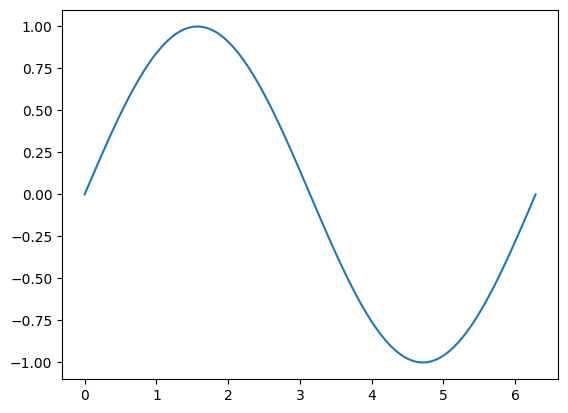

In [19]:
xs = np.linspace(0, 2 * np.pi, 100)

plt.plot(xs, np.sin(xs))
plt.show()

**Вправа 16.** На одному графіку познач дві групи точок різними кольорами і додай легенду.

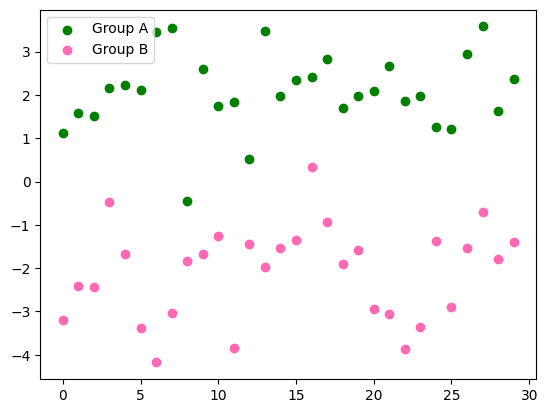

In [20]:
group_a = np.random.randn(30) + 2
group_b = np.random.randn(30) - 2

plt.scatter(range(30), group_a, color="green", label="Group A")
plt.scatter(range(30), group_b, color="hotpink", label="Group B")

plt.legend()
plt.show()

---
## Завдання 1. Лінійна регресія

Тренуємо базовий пайплайн на простій лінійній регресії з одним параметром.

$$y = w \cdot x + b + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 1)$$

In [21]:
TASK1_TRUE_W = 2.0
TASK1_TRUE_B = 1.0
TASK1_N = 300

x1 = torch.empty(TASK1_N, 1).uniform_(-5, 5)
noise = 1.0 * torch.randn(TASK1_N, 1)
y1 = TASK1_TRUE_W * x1 + TASK1_TRUE_B + noise

**Вправа 17.** Перш ніж будувати модель — подивись на самі дані.

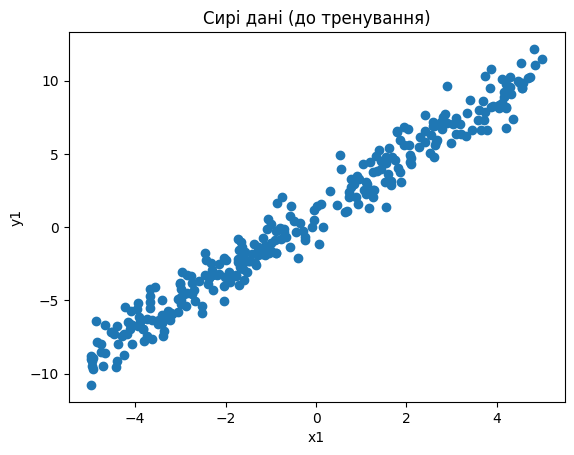

In [22]:
plt.scatter(x1.numpy(), y1.numpy())

plt.xlabel("x1")
plt.ylabel("y1")
plt.title("Сирі дані (до тренування)")

plt.show()

**Вправа 18.** Розбий дані на train/val/test (70/15/15). Перемішай дані перед зрізом, інакше спліт вийде не випадковим.

In [23]:
indices = torch.randperm(TASK1_N)

x1_shuffled = x1[indices]
y1_shuffled = y1[indices]

train_size = int(0.7 * TASK1_N)
val_size = int(0.15 * TASK1_N)

x_train1 = x1_shuffled[:train_size]
y_train1 = y1_shuffled[:train_size]

x_val1 = x1_shuffled[train_size:train_size + val_size]
y_val1 = y1_shuffled[train_size:train_size + val_size]

x_test1 = x1_shuffled[train_size + val_size:]
y_test1 = y1_shuffled[train_size + val_size:]

print(f"train/val/test: {len(x_train1)}/{len(x_val1)}/{len(x_test1)}")

train/val/test: 210/45/45


**Вправа 19.** Нижче — готовий цикл навчання, кожен крок підписаний окремо. Просто запусти обидві комірки й подивись, як модель наближається до `true` за 100 епох (знімки кожні 30 епох).

In [24]:
task1_model = torch.nn.Linear(in_features=1, out_features=1)
optimizer = torch.optim.SGD(task1_model.parameters(), lr=0.05)
loss_fn = torch.nn.MSELoss()

x_line = torch.linspace(-5, 5, 100).unsqueeze(1)  # сітка для візуалізації лінії
snapshots = []  # (epoch, w, b, y_line_pred) кожні 30 епох

for epoch in range(100):
    # обнулити градієнти з попереднього кроку
    optimizer.zero_grad()
    # forward -- прогноз моделі на поточних w, b
    y_pred = task1_model(x_train1)
    # loss -- наскільки прогноз відрізняється від y_train1
    loss = loss_fn(y_pred, y_train1)
    # backward -- градієнти loss за w і b
    loss.backward()
    # крок оптимізатора -- оновити w і b
    optimizer.step()

    if epoch % 30 == 0 or epoch == 99:
        with torch.no_grad():
            y_line_pred = task1_model(x_line)
        snapshots.append((epoch, task1_model.weight.item(), task1_model.bias.item(), y_line_pred))
        print(f"epoch {epoch:4d}  loss={loss.item():.6f}  "
              f"w={task1_model.weight.item():.4f} (true {TASK1_TRUE_W})  "
              f"b={task1_model.bias.item():.4f} (true {TASK1_TRUE_B})")


epoch    0  loss=10.796704  w=1.7971 (true 2.0)  b=-0.2009 (true 1.0)
epoch   30  loss=1.030498  w=1.9806 (true 2.0)  b=1.0221 (true 1.0)
epoch   60  loss=1.026565  w=1.9829 (true 2.0)  b=1.0764 (true 1.0)
epoch   90  loss=1.026557  w=1.9830 (true 2.0)  b=1.0788 (true 1.0)
epoch   99  loss=1.026557  w=1.9830 (true 2.0)  b=1.0789 (true 1.0)


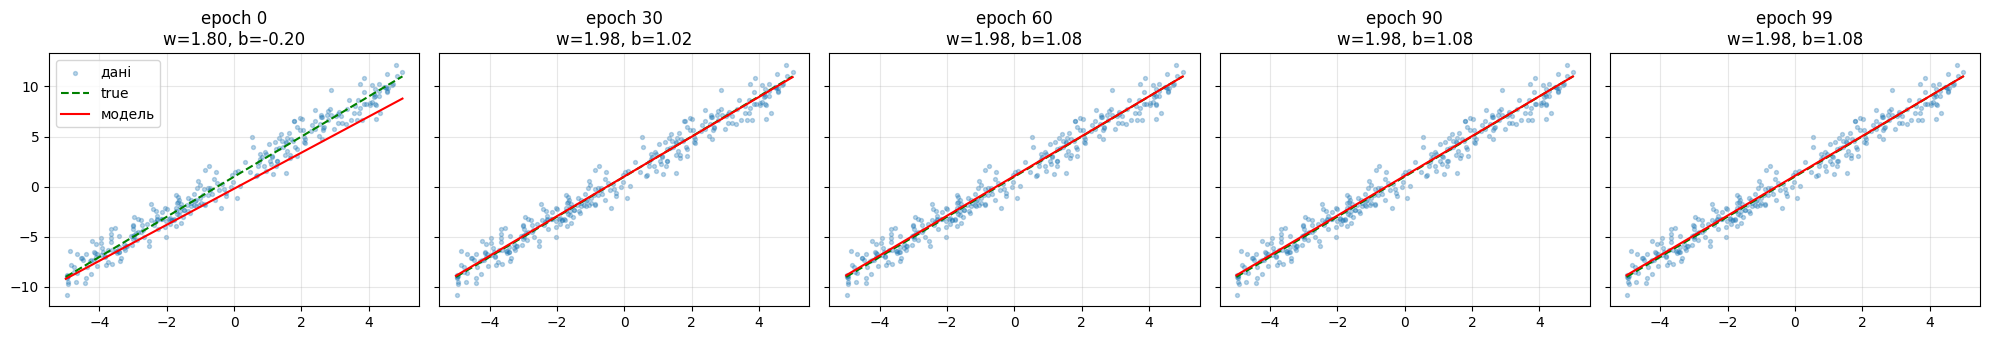

In [25]:
with torch.no_grad():
    y_line_true = TASK1_TRUE_W * x_line + TASK1_TRUE_B

fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 3.5), sharey=True)
for ax, (epoch, w, b, y_line_pred) in zip(axes, snapshots):
    ax.scatter(x1.numpy(), y1.numpy(), s=8, alpha=0.3, label="дані")
    ax.plot(x_line.numpy(), y_line_true.numpy(), "g--", label="true")
    ax.plot(x_line.numpy(), y_line_pred.numpy(), "r-", label="модель")
    ax.set_title(f"epoch {epoch}\nw={w:.2f}, b={b:.2f}")
    ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()


**Вправа 20.** Придумай власний напів-реальний сценарій лінійної залежності
(наприклад: кількість з'їдених пачок чіпсів на тиждень → індекс маси тіла;
години сну → продуктивність; щось своє). У markdown-комірці перед кодом
опиши сценарій: яку залежність ти
закладаєш ($w$, $b$) і чому саме такі значення видались тобі правдоподібними.
Згенеруй дані з шумом, збережи їх у CSV файл (за зразком відповідної частини лекції)
і натренуй лінійну регресію за тим самим патерном — спліт, цикл навчання, перевірка на test.
Організуй код тренування у логічні перевикористовувані функції.

***Обрала такий сценарій: залежність тривалості планки від кількості тренувань за місяць.***

Нехай x - кількість тренувань за місяць, а y - тривалість планки в секундах. Для генерації даних використовується залежність y = 3.5x + 25 + шум.

Значення w = 3.5 обрано як умовний коефіцієнт покращення результату: у моделі кожне додаткове тренування за місяць збільшує очікуваний час утримання планки приблизно на 3,5 секунди

Значення b = 25 задає умовний початковий рівень. Тобто при x = 0 модель прогнозує приблизно 25 секунд планки навіть без тренувань у поточному місяці, оскільки людина вже може мати певний базовий рівень фізичної підготовки

За таких параметрів при 20 тренуваннях очікуваний результат становить приблизно 95 секунд, що дає помітну, але не надто різку лінійну залежність

Випадковий шум додається тому, що реальний результат залежить не лише від кількості тренувань, а й від рівня підготовки, відновлення, сну та інших індивідуальних факторів





In [26]:
MY_TRUE_W = 3.5
MY_TRUE_B = 25.0
N = 200

set_seed()

x = torch.rand(N, 1) * 20
noise = torch.randn(N, 1) * 5

y = MY_TRUE_W * x + MY_TRUE_B + noise

print("x shape:", x.shape)
print("y shape:", y.shape)

print("\nПерші значення x:")
print(x[:5])

print("\nПерші значення y:")
print(y[:5])

x shape: torch.Size([200, 1])
y shape: torch.Size([200, 1])

Перші значення x:
tensor([[17.6454],
        [18.3001],
        [ 7.6573],
        [19.1861],
        [ 7.8090]])

Перші значення y:
tensor([[85.9622],
        [86.9256],
        [56.5216],
        [91.2267],
        [57.6354]])


In [27]:
df = pd.DataFrame({
    "trainings_per_month": x.squeeze().numpy(),
    "plank_seconds": y.squeeze().numpy()
})

csv_path = os.path.join(ARTIFACT_DIR, "dataset.csv")
df.to_csv(csv_path, index=False)

print("Dataset saved to:", csv_path)

df.head()

Dataset saved to: /content/drive/MyDrive/ai_systems/lab1/dataset.csv


,trainings_per_month,plank_seconds
0,17.645386,85.962196
1,18.300079,86.925560
2,7.657275,56.521614
3,19.186113,91.226723
4,7.808964,57.635372


In [28]:
def split_data(x, y):
    set_seed()

    indices = torch.randperm(len(x))

    x = x[indices]
    y = y[indices]

    n_train = int(0.70 * len(x))
    n_val = int(0.15 * len(x))

    x_train = x[:n_train]
    y_train = y[:n_train]

    x_val = x[n_train:n_train + n_val]
    y_val = y[n_train:n_train + n_val]

    x_test = x[n_train + n_val:]
    y_test = y[n_train + n_val:]

    return x_train, y_train, x_val, y_val, x_test, y_test


x_train, y_train, x_val, y_val, x_test, y_test = split_data(x, y)

print("Train:", len(x_train))
print("Validation:", len(x_val))
print("Test:", len(x_test))

Train: 140
Validation: 30
Test: 30


In [29]:
def train_model(x_train, y_train, x_val, y_val, epochs=1000, lr=0.001):
    set_seed()

    model = torch.nn.Linear(1, 1)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    loss_fn = torch.nn.MSELoss()

    for epoch in range(epochs):
        model.train()

        optimizer.zero_grad()

        y_pred = model(x_train)
        loss = loss_fn(y_pred, y_train)

        loss.backward()
        optimizer.step()

        if epoch % 200 == 0 or epoch == epochs - 1:
            model.eval()

            with torch.no_grad():
                val_pred = model(x_val)
                val_loss = loss_fn(val_pred, y_val)

            print(
                f"epoch {epoch:4d} "
                f"train_loss={loss.item():.4f} "
                f"val_loss={val_loss.item():.4f} "
                f"w={model.weight.item():.4f} "
                f"b={model.bias.item():.4f}"
            )

    return model

In [30]:
my_model = train_model(
    x_train,
    y_train,
    x_val,
    y_val,
    epochs=5000,
    lr=0.001
)

epoch    0 train_loss=2813.8503 val_loss=1701.7046 w=1.8908 b=0.9309
epoch  200 train_loss=152.4726 val_loss=127.3226 w=5.2035 b=3.7346
epoch  400 train_loss=126.5326 val_loss=105.5274 w=5.0274 b=6.0034
epoch  600 train_loss=105.6949 val_loss=88.0662 w=4.8696 b=8.0369
epoch  800 train_loss=88.9559 val_loss=74.0816 w=4.7281 b=9.8595
epoch 1000 train_loss=75.5095 val_loss=62.8855 w=4.6013 b=11.4930
epoch 1200 train_loss=64.7079 val_loss=53.9254 w=4.4877 b=12.9570
epoch 1400 train_loss=56.0310 val_loss=46.7579 w=4.3859 b=14.2692
epoch 1600 train_loss=49.0607 val_loss=41.0275 w=4.2946 b=15.4453
epoch 1800 train_loss=43.4615 val_loss=36.4484 w=4.2128 b=16.4994
epoch 2000 train_loss=38.9637 val_loss=32.7919 w=4.1394 b=17.4442
epoch 2200 train_loss=35.3506 val_loss=29.8742 w=4.0737 b=18.2909
epoch 2400 train_loss=32.4481 val_loss=27.5479 w=4.0148 b=19.0499
epoch 2600 train_loss=30.1167 val_loss=25.6949 w=3.9620 b=19.7300
epoch 2800 train_loss=28.2437 val_loss=24.2204 w=3.9147 b=20.3397
epoch 

In [31]:
def evaluate_model(model, x_test, y_test):
    model.eval()
    loss_fn = torch.nn.MSELoss()

    with torch.no_grad():
        predictions = model(x_test)
        test_loss = loss_fn(predictions, y_test)

    return test_loss.item()


test_loss = evaluate_model(my_model, x_test, y_test)

print("Test loss:", test_loss)
print("Learned w:", my_model.weight.item())
print("Learned b:", my_model.bias.item())
print("True w:", MY_TRUE_W)
print("True b:", MY_TRUE_B)

Test loss: 17.86208724975586
Learned w: 3.62850022315979
Learned b: 24.027238845825195
True w: 3.5
True b: 25.0


Отже було згенеровано синтетичні дані для залежності тривалості планки від кількості тренувань за місяць за формулою y = 3.5x + 25 + шум. Після навчання модель отримала параметри w ≈ 3.63 та b ≈ 24.03, що близькі до заданих значень w = 3.5 і b = 25. Значення test loss становило приблизно 17.86, тому модель коректно відтворила закладену лінійну залежність навіть з урахуванням шуму

**Вправа 21.** Збережи натреновану модель на своєму гугл диску у файлі з назвою `model.pt`.
Збережений файл потрібно буде також здати разом з лабою.

In [32]:
model_path = os.path.join(ARTIFACT_DIR, "model.pt")

torch.save(my_model.state_dict(), model_path)

print("Model saved to:", model_path)

Model saved to: /content/drive/MyDrive/ai_systems/lab1/model.pt


**Вправа 22.** Встанови [Gradio](https://gradio.app/)
```
!pip install -q gradio
import gradio as gr
```
Завантаж свою модель, збережену в попередній вправі і створи інтерактивну аппку.

In [33]:
!pip install -q gradio
import gradio as gr

In [34]:
model_path = "/content/drive/MyDrive/ai_systems/lab1/model.pt"

loaded_model = torch.nn.Linear(1, 1)

loaded_model.load_state_dict(
    torch.load(model_path, map_location="cpu")
)

loaded_model.eval()

print("Модель завантажено")
print("w =", loaded_model.weight.item())
print("b =", loaded_model.bias.item())

Модель завантажено
w = 3.62850022315979
b = 24.027238845825195


In [35]:
def predict_plank(trainings):
    x_input = torch.tensor(
        [[float(trainings)]],
        dtype=torch.float32
    )

    with torch.no_grad():
        prediction = loaded_model(x_input)

    return round(prediction.item(), 2)

In [36]:
app = gr.Interface(
    fn=predict_plank,
    inputs=gr.Number(
        label="Кількість тренувань за місяць"
    ),
    outputs=gr.Number(
        label="Прогнозована тривалість планки, секунд"
    ),
    title="Прогноз тривалості планки",
    description="Введіть кількість тренувань за місяць, щоб отримати прогноз тривалості планки."
)

app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8db49838e27f5339d3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
### Як здавати лабу
У [форму](https://forms.gle/5qxRYshxKknBXDCz8) здати посилання на **публічний** репозиторій, який містить:
1. **Цей ноутбук з усіма виконаними вправами**. Ноутбук має запускатися зверху до низу (Run All) в будь-якому середовищі без помилок.
2. **Додаткові скріншоти** по ходу виконання лаби (якими Ви доводите, що справді виконували цбю лабу).
3. Створений по ходу виконання лаби **csv файл** з даними і **pt файл** з моделлю.
4. Структура файлів на репозиторії, **точно дотримуйтесь, інакше не зарахується лаба**:
```
    /lab1/linear_models_lab.ipynb
    /lab1/screenshots/*
    /lab1/dataset.csv
    /lab1/model.pt
```